In [1]:
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt
FILE_DIR = pathlib.Path('/Users/ashhadulislam/projects/general_data/CMI/ Detect Behavior with Sensor Data/cmi-detect-behavior-with-sensor-data/')  
SEED = 42


['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject', 'orientation', 'behavior', 'phase', 'gesture', 'acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z', 'adult_child', 'age', 'sex', 'handedness', 'height_cm', 'shoulder_to_wrist_cm', 'elbow_to_wrist_cm']
(574945, 23)


rot_w                   3692
rot_z                   3692
rot_y                   3692
rot_x                   3692
row_id                     0
shoulder_to_wrist_cm       0
height_cm                  0
handedness                 0
sex                        0
age                        0
adult_child                0
acc_z                      0
sequence_type              0
acc_y                      0
acc_x                      0
gesture                    0
phase                      0
behavior                   0
orientation                0
subject                    0
sequence_counter           0
sequence_id                0
elbow_to_wrist_cm          0
dtype: int64

(571253, 23)


row_id                  0
rot_w                   0
shoulder_to_wrist_cm    0
height_cm               0
handedness              0
sex                     0
age                     0
adult_child             0
rot_z                   0
rot_y                   0
rot_x                   0
acc_z                   0
sequence_type           0
acc_y                   0
acc_x                   0
gesture                 0
phase                   0
behavior                0
orientation             0
subject                 0
sequence_counter        0
sequence_id             0
elbow_to_wrist_cm       0
dtype: int64

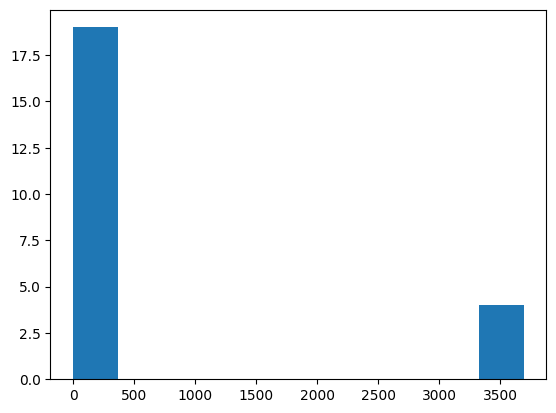

In [2]:

train_df=pd.read_csv(FILE_DIR/'train.csv')
train_demographics_df = pd.read_csv(FILE_DIR / 'train_demographics.csv')
train_df = pd.merge(train_df, train_demographics_df, how="left", on="subject")

select_cols=[]
for col in train_df.columns:
    if col.startswith('thm_') or col.startswith('tof_'):
        continue
    select_cols.append(col)
print(select_cols)

train_df=train_df[select_cols]

print(train_df.shape)
with pd.option_context('display.max_rows', None):
    display(train_df.isna().sum().sort_values(ascending=False))#

NA_vals=train_df.isna().sum().sort_values(ascending=False).values
plt.hist(NA_vals)    

train_df.dropna(inplace=True)

print(train_df.shape)
with pd.option_context('display.max_rows', None):
    display(train_df.isna().sum().sort_values(ascending=False))#

In [3]:
print(train_df.shape)
uniq_gestures=train_df.gesture.unique()
#print(uniq_gestures)
chosen_gesture=uniq_gestures[2]
print(chosen_gesture)
df_gesture=train_df[train_df['gesture']==chosen_gesture]
print(df_gesture.shape)
uniq_subjects=df_gesture.subject.unique()
#print(uniq_subjects)
chosen_subject=uniq_subjects[2]
print(chosen_subject)
df_gesture_subject=df_gesture[df_gesture['subject']==chosen_subject]
print(df_gesture_subject.shape)
uniq_sequences=df_gesture_subject.sequence_id.unique()
#print(uniq_sequences)
chosen_sequence=uniq_sequences[1]
print(chosen_sequence)
df_gesture_subject_sequence=df_gesture_subject[df_gesture_subject['sequence_id']==chosen_sequence]
print(df_gesture_subject_sequence.shape)

(571253, 23)
Write name on leg
(10138, 23)
SUBJ_041243
(170, 23)
SEQ_008172
(115, 23)


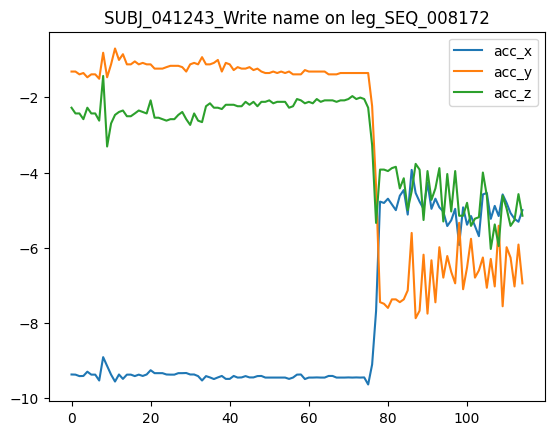

In [4]:
series_cols=[
            'acc_x','acc_y','acc_z',
             #'rot_x','rot_y','rot_z',
             ]
tseries=df_gesture_subject_sequence[series_cols].values
for i in range(len(series_cols)):
    plt.plot(tseries[:,i],label=series_cols[i])    
plt.title(f'{chosen_subject}_{chosen_gesture}_{chosen_sequence}')
plt.legend()
plt.show()

## Can we apply wavelet transform

In [5]:
import pywt
import random
discrete_wavelets = pywt.wavelist(kind='discrete')
print(discrete_wavelets)
selected_wavelet_fams=random.sample(discrete_wavelets,15)

['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'haar', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 'rbio2.8', 'rbio3.1', 'rbio3.3', 'rbio3.5', 'rbio3.7', 'rbio3.9', 'rbio4.4', 'rbio5.5', 'rbio6.8', 'sym2', 'sym3', 'sym4', 'sym5', 'sym6', 'sym7', 'sym8', 'sym9', 'sym10', 'sym11', 'sym12', 'sym13', 'sym14', 'sym15', 'sym16', 'sym17', 'sym18', 'sym19', 'sym20']


In [6]:
values=[]
for fam in selected_wavelet_fams:
    for i in range(len(series_cols)):
        (cA, cD) = pywt.dwt(tseries[:,i], 'db1')
        values.append(cA)
        values.append(cD)
values=np.array(values)    
print(values.shape)

(90, 58)


Text(0.5, 1.0, 'SUBJ_041243_Write name on leg_SEQ_008172')

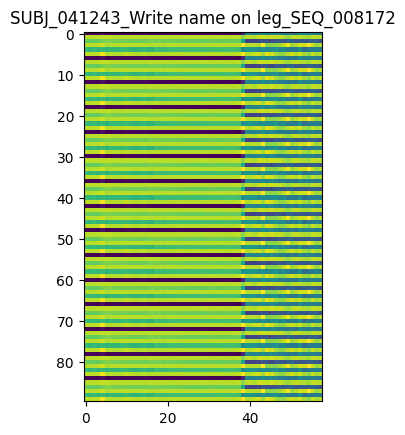

In [7]:
plt.imshow(values)
plt.title(f'{chosen_subject}_{chosen_gesture}_{chosen_sequence}')

In [8]:
while values.shape[0]>values.shape[1]:
    new_values=[]
    for i in range(values.shape[0]-1):
        this=values[i,:]
        next=values[i+1,:]        
        new=(this+next)/2
        #print(new)
        new_values.append(new)
    new_values=np.array(new_values)
    #print(new_values.shape)
    values=new_values



Text(0.5, 1.0, 'SUBJ_041243_Write name on leg_SEQ_008172')

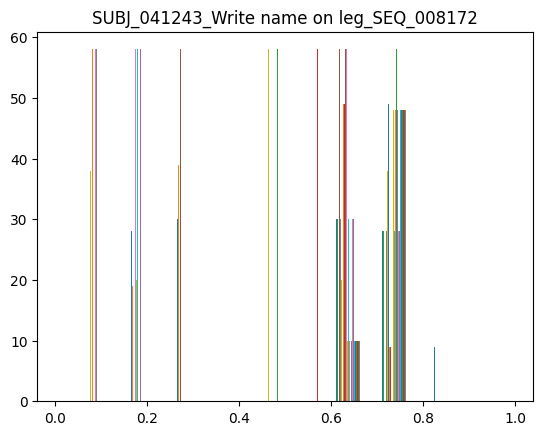

In [9]:
values=(values-np.min(values))/(np.max(values)-np.min(values))
plt.hist(values)
plt.title(f'{chosen_subject}_{chosen_gesture}_{chosen_sequence}')

Text(0.5, 1.0, 'SUBJ_041243_Write name on leg_SEQ_008172')

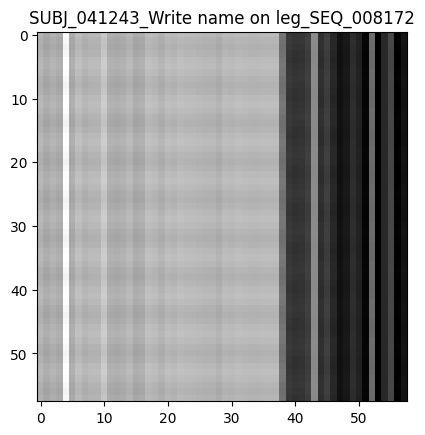

In [10]:
plt.imshow(values[:,:],cmap='gray')
plt.title(f'{chosen_subject}_{chosen_gesture}_{chosen_sequence}')

In [11]:
print(np.min(values),np.max(values))

0.0 1.0
